In [1]:
!pip install gudhi --quiet
!pip install scikit-tda --quiet

In [2]:
import numpy as np
import matplotlib.pyplot as plt 
from mpl_toolkits.mplot3d import Axes3D
import gudhi as gd
import tadasets
import ripser
import persim
from persim import PersLandscapeApprox, PersLandscapeExact
from persim.landscapes import plot_landscape_simple

In [3]:
np.random.seed(4052003)

In [4]:
data = tadasets.torus(n = 1000, noise = 0)

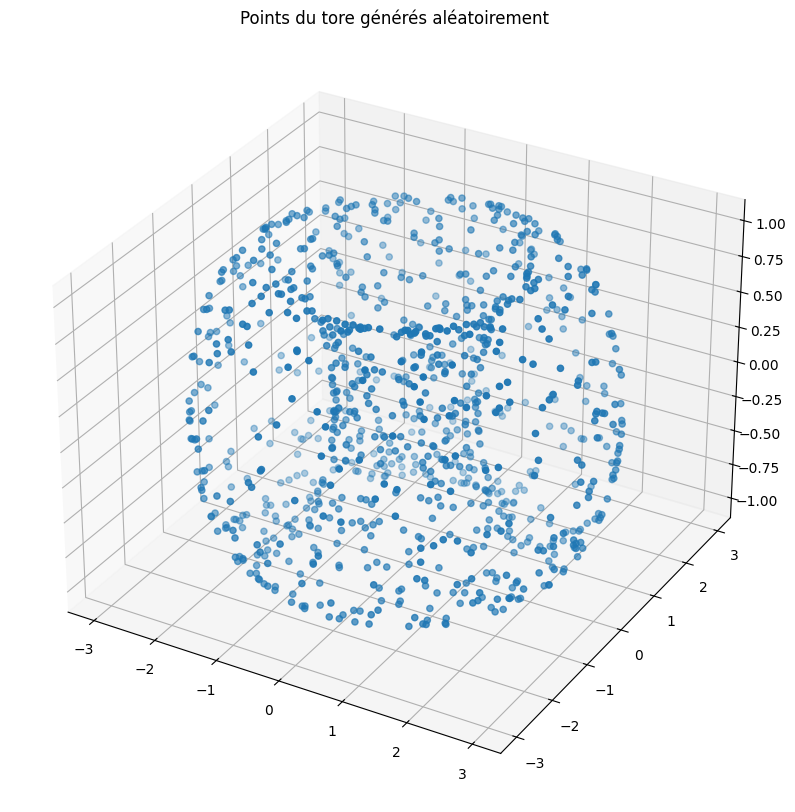

In [5]:
fig = plt.figure(figsize=(10, 10))
ax = fig.add_subplot(1,1,1, projection='3d')
ax.scatter(data[:,0], data[:, 1], data[:,2])
ax.set_title("Points du tore générés aléatoirement")
plt.savefig('tore.png')

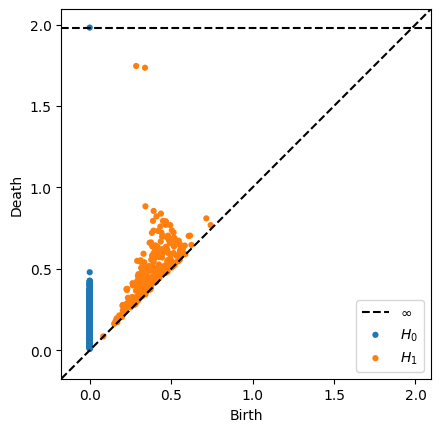

In [6]:
dgm = ripser.ripser(data, maxdim = 1)['dgms']
persim.plot_diagrams(
    dgm,
    show=False
)
plt.savefig("diagram.png")

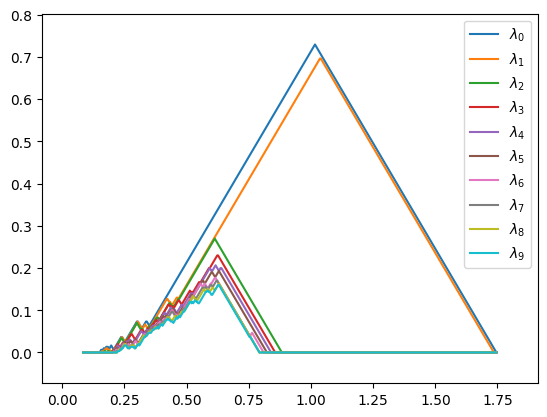

In [8]:
pla = PersLandscapeApprox(dgms=dgm,hom_deg=1)
ax = plot_landscape_simple(pla, depth_range = range(10))
plt.savefig("pl.png")

- Point bleu : sur la ligne pointillet --> une seule composante persiste, le tore est connexe par arcs
- Points oranges : Deux groupes de points éloignés de la première bissectrice (trou du tube, trou central)
- Points verts : Un groupe (surface fermée)

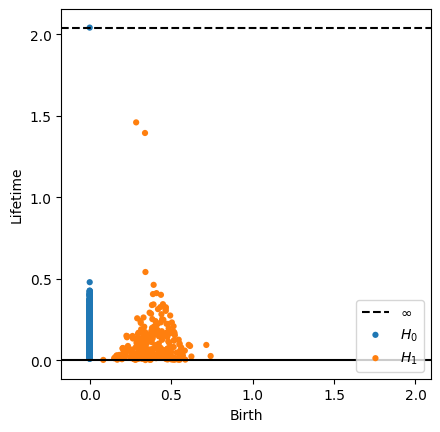

In [18]:
persim.plot_diagrams(
    dgm,
    lifetime=True,
    show=False
)
plt.savefig("persistance.png")

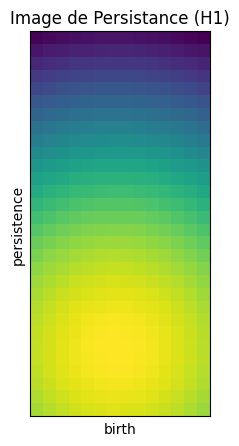

In [17]:
from persim import PersistenceImager

"""def weighting_logistic(birth, lifetime, k=10, x0=0.2):
    
    birth : tableau des naissances (envoyé automatiquement par persim)
    lifetime : tableau des persistances (death - birth) (envoyé automatiquement)
    k, x0 : vos paramètres personnalisés
    # On applique la sigmoïde directement sur la lifetime
    weights = 1 / (1 + np.exp(-k * (lifetime - x0)))
    return weights

mes_parametres = {'k': 10, 'x0': 0.1} # Ajustez x0 selon vos données !

pimager = PersistenceImager(
    pixel_size=0.07, 
    weight=weighting_logistic,      # Votre fonction
    weight_params=mes_parametres    # <--- INDISPENSABLE pour écraser le 'n' par défaut
)

fig2 = plt.figure(figsize = (6, 6))
ax = fig2.add_subplot(1, 1, 1)
pimager.plot_image(imgs[0], ax=ax)"""


from persim import PersistenceImager

# 1. On définit la fonction de poids CORRECTE (sans le 'n')
def weighting_logistic(birth, lifetime, k=10, x0=0.2):
    # Tout ce qui est en dessous de x0 sera écrasé vers 0
    return 1 / (1 + np.exp(-k * (lifetime - x0)))

# 2. On configure l'imageur
pimager = PersistenceImager(
    pixel_size=0.05,  # Un peu plus fin que 0.07
    weight=weighting_logistic, 
    weight_params={'k': 20, 'x0': 0.2} # <-- Augmentez x0 pour cacher le bruit
)

# 3. Sélection des données (H1 uniquement)
# dgm[1] est l'array des points H1. On le met dans une liste [ ... ] pour fit()
h1_diagram = [dgm[1]] 

pimager.fit(h1_diagram)
imgs = pimager.transform(h1_diagram)

# 4. Affichage
fig, ax = plt.subplots(figsize=(5,5))
pimager.plot_image(imgs[0], ax=ax)
plt.title("Image de Persistance (H1)")
plt.savefig("persim.png")


- Beaucoup de petit cycles peu persistants (bas-gauche en vert) --> Composantes H0 fusionnent vite)
- Cycles H1 dans la zone centrale : Apparaissent plus tard et persistent
- Cycles H2 non détectés (devraient apparaître à la fin et persister) mais cases foncées. 

In [9]:
"""rips_complex = gd.RipsComplex(points=data, max_edge_length=5)
simplex_tree = rips_complex.create_simplex_tree(max_dimension=3)
diag = simplex_tree.persistence(min_persistence=0.4)

gd.plot_persistence_barcode(diag)
plt.show()"""

'rips_complex = gd.RipsComplex(points=data, max_edge_length=5)\nsimplex_tree = rips_complex.create_simplex_tree(max_dimension=3)\ndiag = simplex_tree.persistence(min_persistence=0.4)\n\ngd.plot_persistence_barcode(diag)\nplt.show()'

Comment avant, H2 mal détecté. On a du mal aussi à voir que H1 = 2. 

Text(0.5, 0.92, 'Points du tore générés aléatoirement, Bruit = 0.05')

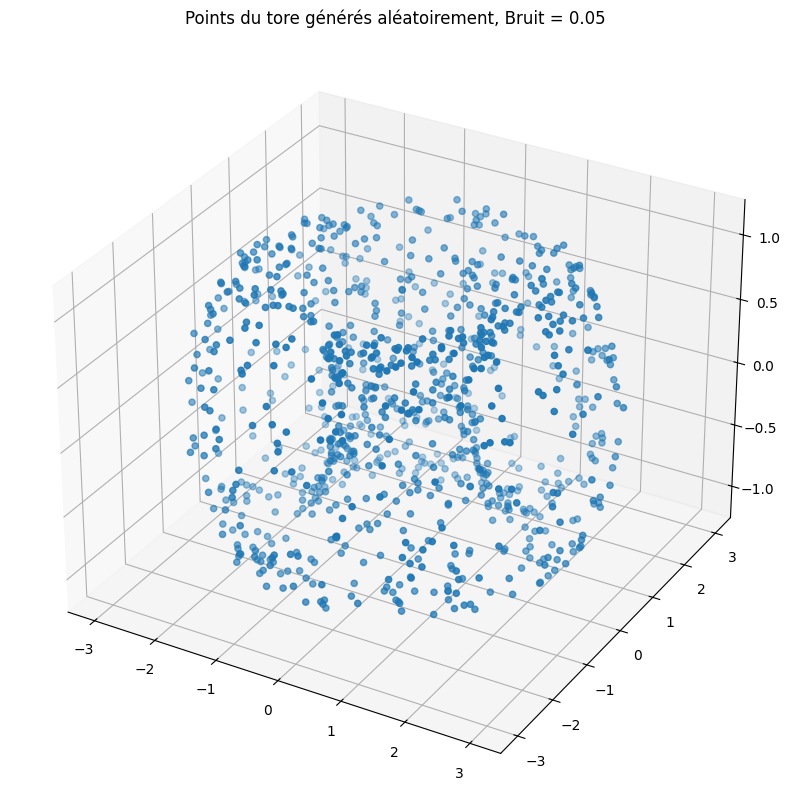

In [10]:
#Deuxième session 

data_05 = tadasets.torus(n = 1000, noise = 0.05)

fig = plt.figure(figsize=(10, 10))
ax = fig.add_subplot(1,1,1, projection='3d')
ax.scatter(data_05[:,0], data_05[:, 1], data_05[:,2])
ax.set_title("Points du tore générés aléatoirement, Bruit = 0.05")

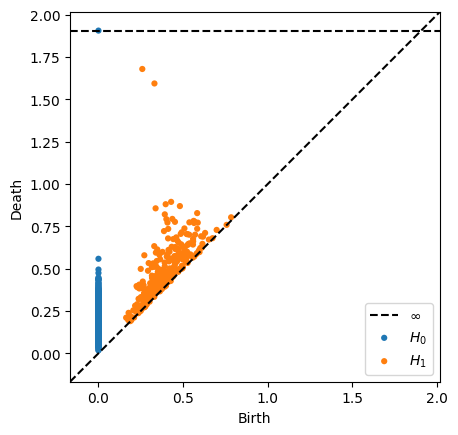

In [11]:
dgm = ripser.ripser(data_05, maxdim = 1)['dgms']
persim.plot_diagrams(
    dgm,
    show=True
)

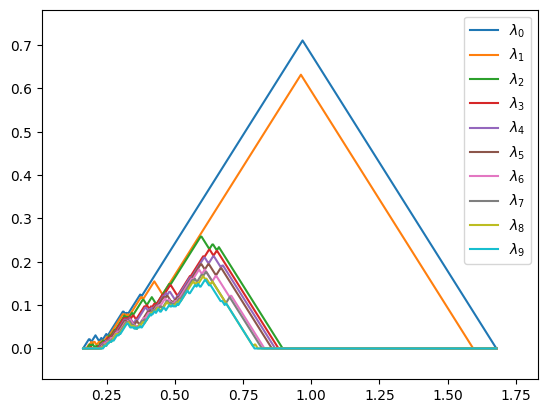

In [12]:
pla = PersLandscapeApprox(dgms=dgm,hom_deg=1)
ax = plot_landscape_simple(pla, depth_range = range(10))

Text(0.5, 0.92, 'Points du tore générés aléatoirement, Bruit = 0.1')

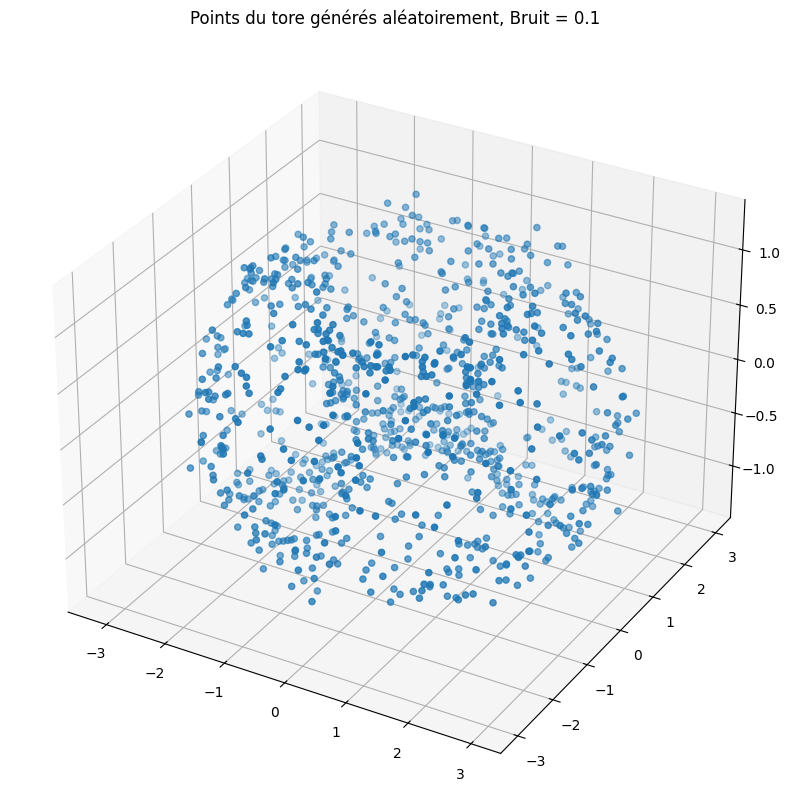

In [13]:
data = tadasets.torus(n = 1000, noise = 0.1)

fig = plt.figure(figsize=(10, 10))
ax = fig.add_subplot(1,1,1, projection='3d')
ax.scatter(data[:,0], data[:, 1], data[:,2])
ax.set_title("Points du tore générés aléatoirement, Bruit = 0.1")

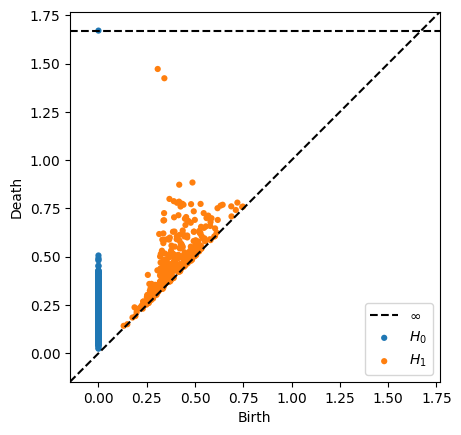

In [14]:
dgm = ripser.ripser(data, maxdim = 1)['dgms']
persim.plot_diagrams(
    dgm,
    show=True
)

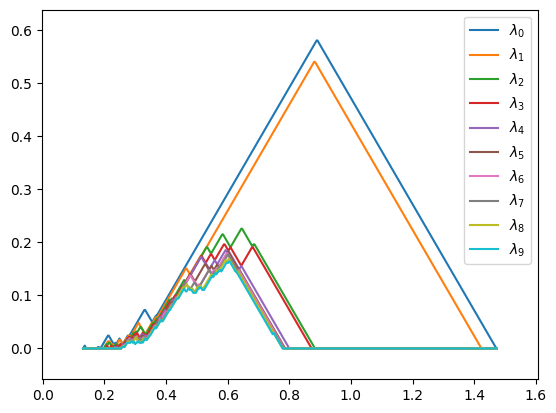

In [15]:
pla = PersLandscapeApprox(dgms=dgm,hom_deg=1)
ax = plot_landscape_simple(pla, depth_range = range(10))

Text(0.5, 0.92, 'Points du tore générés aléatoirement, Bruit = 0.2')

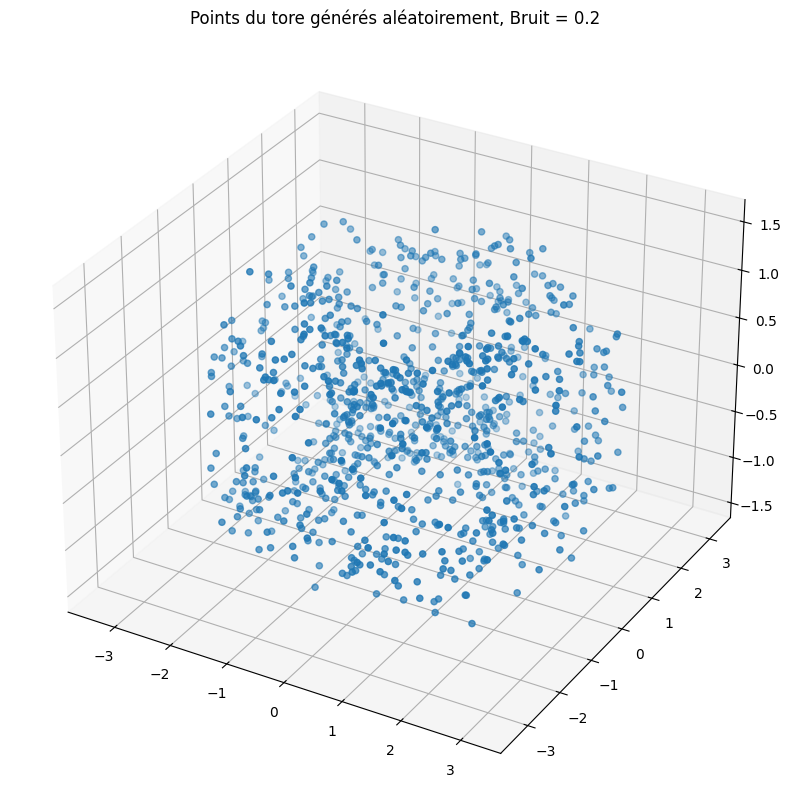

In [16]:
data = tadasets.torus(n = 1000, noise = 0.2)

fig = plt.figure(figsize=(10, 10))
ax = fig.add_subplot(1,1,1, projection='3d')
ax.scatter(data[:,0], data[:, 1], data[:,2])
ax.set_title("Points du tore générés aléatoirement, Bruit = 0.2")

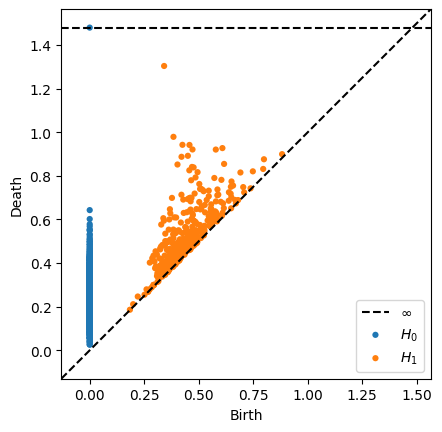

In [17]:
dgm = ripser.ripser(data, maxdim = 1)['dgms']
persim.plot_diagrams(
    dgm,
    show=True
)

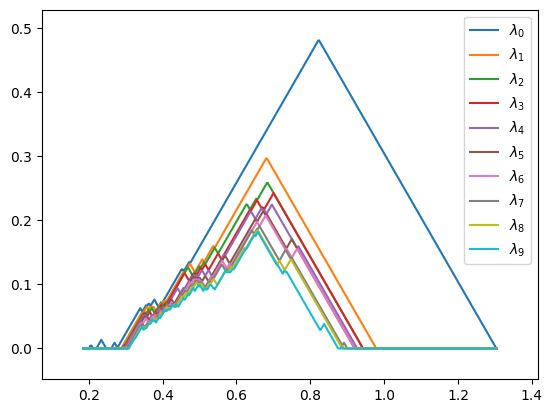

In [18]:
pla = PersLandscapeApprox(dgms=dgm,hom_deg=1)
ax = plot_landscape_simple(pla, depth_range = range(10))

In [19]:
#La caractéristiques principale en H1 vers 1.4 semble persister, même si on voit que plus le bruit augmente,
#plus les paysages de persistence ont l'air "agités"

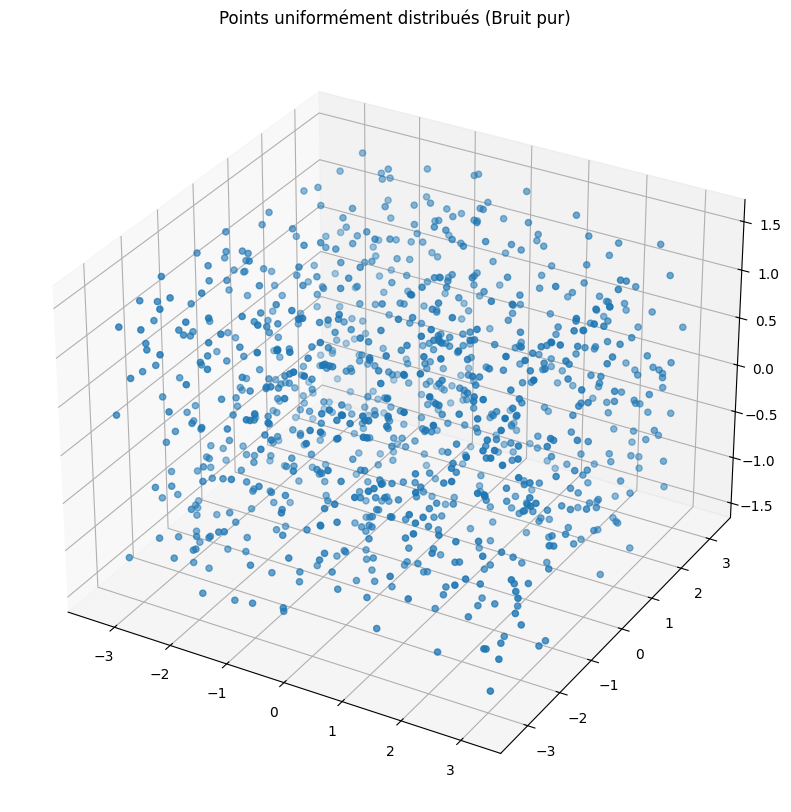

In [20]:
x_min, x_max = data[:, 0].min(), data[:, 0].max()
y_min, y_max = data[:, 1].min(), data[:, 1].max()
z_min, z_max = data[:, 2].min(), data[:, 2].max()


n_points = 1000  
uniform_data = np.random.uniform(
    low=[x_min, y_min, z_min],
    high=[x_max, y_max, z_max],
    size=(n_points, 3)
)


fig = plt.figure(figsize=(10, 10))
ax = fig.add_subplot(1, 1, 1, projection='3d')
ax.scatter(uniform_data[:, 0], uniform_data[:, 1], uniform_data[:, 2])
ax.set_title("Points uniformément distribués (Bruit pur)")
plt.show()

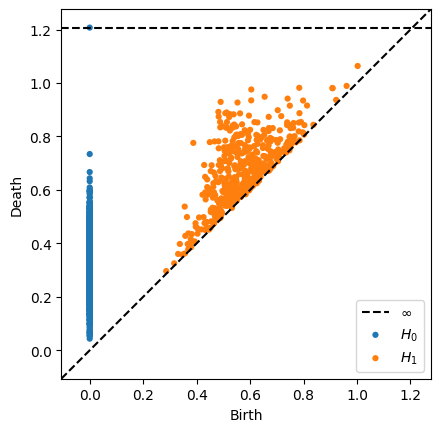

In [21]:
dgm = ripser.ripser(uniform_data, maxdim = 1)['dgms']
persim.plot_diagrams(
    dgm,
    show=True
)

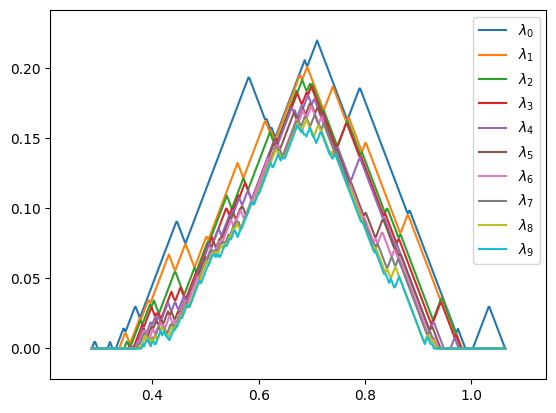

In [22]:
pla = PersLandscapeApprox(dgms=dgm,hom_deg=1)
ax = plot_landscape_simple(pla, depth_range = range(10))

In [23]:
#La différence entre le persistence landscape du bruit pur et du tore bruité à 0.2 n'est pas si 
#flagrante !

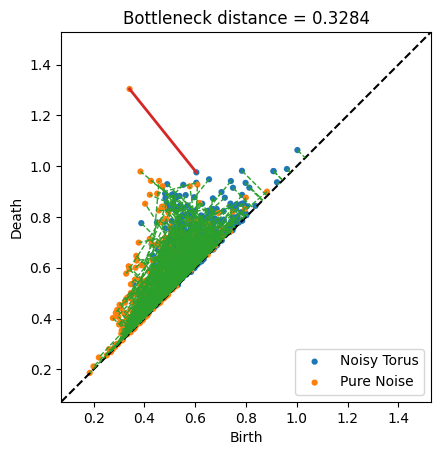

In [24]:
dgm_unif = ripser.ripser(uniform_data)['dgms'][1]
dgm_torus = ripser.ripser(data)['dgms'][1]

distance_bottleneck, matching = persim.bottleneck(dgm_unif, dgm_torus, matching=True)

persim.bottleneck_matching(
    dgm_unif, dgm_torus, matching,
    labels=['Noisy Torus', 'Pure Noise']
)
plt.title(f"Bottleneck distance = {distance_bottleneck:0.4f}",)
plt.show()


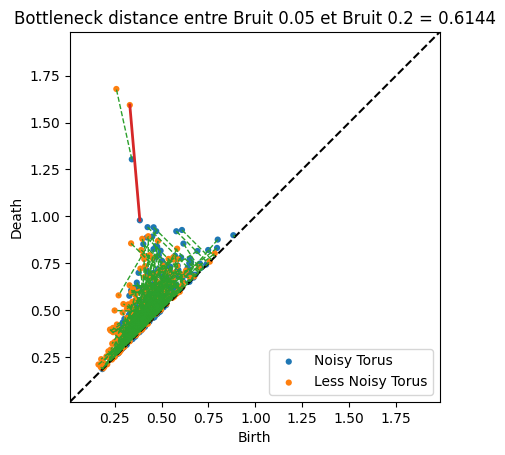

In [25]:


dgm_tore_plus_bruite = ripser.ripser(data)['dgms'][1]
dgm_tore_moins_bruite = ripser.ripser(data_05)['dgms'][1]

distance_bottleneck, matching = persim.bottleneck(dgm_tore_plus_bruite, dgm_tore_moins_bruite, matching=True)

persim.bottleneck_matching(
    dgm_tore_plus_bruite, dgm_tore_moins_bruite, matching,
    labels=['Noisy Torus', 'Less Noisy Torus']
)
plt.title(f"Bottleneck distance entre Bruit 0.05 et Bruit 0.2 = {distance_bottleneck:0.4f}",)
plt.show()